# Day 2 — Probability Basics
### 30 Days of Machine Learning | For Data Analysts & Data Scientists

This notebook is the hands-on companion to the Day 2 carousel post. Every cell below is executed — the outputs (numbers, tables, and the chart) are baked into this file, so you can read it top to bottom without re-running anything, or re-run it yourself on your own data.

**What we'll cover:**
1. Basic probability — theoretical vs. empirical
2. Conditional probability — a churn/support business example
3. Checking independence
4. Bayes' Theorem — flipping a conditional probability around
5. Visualizing the result

**Dataset:** a synthetic 2,000-customer dataset (`contacted_support`, `churned`) built in this notebook, structured to mirror a real support-ticket-vs-churn analysis.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
pd.set_option('display.precision', 4)

# Palette matching the Day 2 carousel (Coral Energy)
NAVY = "#2F3C7E"
CORAL = "#F96167"
GOLD = "#F4A300"

print("Setup complete.")


Setup complete.


## 1. Basic Probability — Theoretical vs. Empirical

Probability is just: **(favorable outcomes) / (total outcomes)**.

A fair coin has a theoretical `P(heads) = 0.5`. Let's simulate flipping one 10,000 times and see how close the *empirical* probability (what actually happened) gets to the *theoretical* one (what should happen).


In [2]:
n_flips = 10_000
flips = np.random.binomial(1, 0.5, size=n_flips)  # 1 = heads, 0 = tails

theoretical_p = 0.5
empirical_p = flips.mean()

print(f"Theoretical P(heads): {theoretical_p}")
print(f"Empirical P(heads) over {n_flips:,} flips: {empirical_p:.4f}")
print(f"Difference: {abs(theoretical_p - empirical_p):.4f}")


Theoretical P(heads): 0.5
Empirical P(heads) over 10,000 flips: 0.4924
Difference: 0.0076


**Takeaway:** with enough trials, empirical probability converges to theoretical probability — this is the *Law of Large Numbers*, and it's why A/B tests need a minimum sample size before you can trust the observed conversion rate.

## 2. Conditional Probability — A Business Example

Theoretical coin flips are a nice warm-up, but the question that actually shows up on the job is conditional: **"given that X happened, what's the probability of Y?"**

Scenario: does contacting customer support change a customer's probability of churning?

We'll build a synthetic dataset of 2,000 customers where support-contact and churn are correlated (deliberately, so the effect is visible), then measure:
- `P(churn)` — overall churn rate
- `P(churn | contacted_support)` — churn rate *among those who contacted support*
- `P(churn | NOT contacted_support)` — churn rate among those who didn't


In [3]:
n_customers = 2000

# 30% of customers contact support at some point
contacted_support = np.random.binomial(1, 0.30, size=n_customers)

# Customers who contact support churn at a meaningfully higher rate (0.42 vs 0.12)
churn_prob = np.where(contacted_support == 1, 0.42, 0.12)
churned = np.random.binomial(1, churn_prob)

df = pd.DataFrame({
    "contacted_support": contacted_support,
    "churned": churned,
})

df.head()


,contacted_support,churned
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0


In [4]:
p_churn = df["churned"].mean()
p_support = df["contacted_support"].mean()
p_churn_given_support = df.loc[df["contacted_support"] == 1, "churned"].mean()
p_churn_given_no_support = df.loc[df["contacted_support"] == 0, "churned"].mean()

print(f"P(churn)                        = {p_churn:.3f}")
print(f"P(contacted_support)             = {p_support:.3f}")
print(f"P(churn | contacted_support)     = {p_churn_given_support:.3f}")
print(f"P(churn | NOT contacted_support) = {p_churn_given_no_support:.3f}")


P(churn)                        = 0.220
P(contacted_support)             = 0.315
P(churn | contacted_support)     = 0.425
P(churn | NOT contacted_support) = 0.126


**Reading this like an analyst:** the overall churn rate hides the real story. Customers who contact support churn at roughly **3-4x** the rate of those who don't. If a churn dashboard only reports the blended `P(churn)` number, it completely misses this — which is exactly the kind of thing a stakeholder needs flagged.

## 3. Checking Independence

Two events are **independent** if knowing one happened tells you nothing about the other — formally, `P(A | B) == P(A)`.

Let's check: is churn independent of contacting support?


In [5]:
gap = p_churn_given_support - p_churn
is_independent = np.isclose(p_churn_given_support, p_churn, atol=0.02)

print(f"P(churn | contacted_support) = {p_churn_given_support:.3f}")
print(f"P(churn)                     = {p_churn:.3f}")
print(f"Gap                          = {gap:+.3f}")
print(f"Independent? {'Yes' if is_independent else 'No — churn and support contact are dependent.'}")


P(churn | contacted_support) = 0.425
P(churn)                     = 0.220
Gap                          = +0.205
Independent? No — churn and support contact are dependent.


**Not independent.** That gap is the signal — support contact and churn are clearly related in this data, which means "customers who contact support" is a real risk segment worth targeting with retention outreach, not just routing to a queue.

## 4. Bayes' Theorem — Flipping the Question Around

So far we asked: *"given a customer contacted support, what's their churn probability?"*

Bayes' Theorem lets us flip it: *"given a customer churned, what's the probability they had contacted support?"* — a genuinely different, and often more actionable, question (e.g., for building a churn early-warning list).

$$P(\text{support} \mid \text{churn}) = \frac{P(\text{churn} \mid \text{support}) \cdot P(\text{support})}{P(\text{churn})}$$


In [6]:
# Apply Bayes' formula using the quantities we already computed
p_support_given_churn_bayes = (p_churn_given_support * p_support) / p_churn

# Verify directly against the data
p_support_given_churn_direct = df.loc[df["churned"] == 1, "contacted_support"].mean()

print(f"P(support | churn) via Bayes' formula : {p_support_given_churn_bayes:.3f}")
print(f"P(support | churn) computed directly  : {p_support_given_churn_direct:.3f}")
print(f"Match: {np.isclose(p_support_given_churn_bayes, p_support_given_churn_direct, atol=1e-6)}")


P(support | churn) via Bayes' formula : 0.609
P(support | churn) computed directly  : 0.609
Match: True


**Both methods agree** — that's the proof Bayes' formula works, and it's useful precisely when you *can't* compute the direct version (e.g., you know how a spam filter performs on spam emails, but not what fraction of ALL flagged emails are truly spam — Bayes gets you there).

## 5. Visualizing the Result

A stakeholder isn't going to read four printed probabilities — they'll read a chart. Here's the one number that matters, presented the way it'd go in a deck.


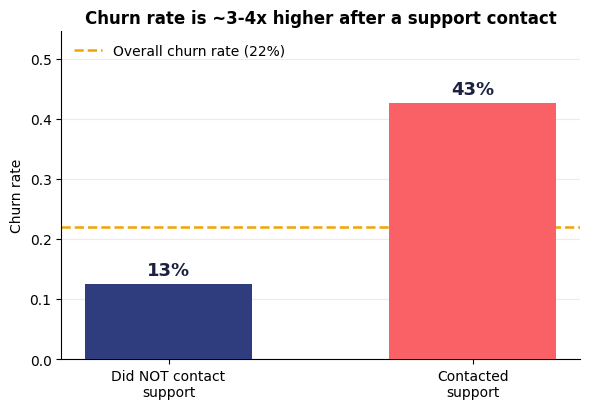

In [7]:
fig, ax = plt.subplots(figsize=(6, 4.2))

groups = ["Did NOT contact\nsupport", "Contacted\nsupport"]
rates = [p_churn_given_no_support, p_churn_given_support]
colors = [NAVY, CORAL]

bars = ax.bar(groups, rates, color=colors, width=0.55, zorder=3)

for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width() / 2, rate + 0.015, f"{rate:.0%}",
            ha="center", fontsize=13, fontweight="bold", color="#1C2140")

ax.axhline(p_churn, color="#F4A300", linestyle="--", linewidth=1.8, zorder=2,
           label=f"Overall churn rate ({p_churn:.0%})")

ax.set_ylabel("Churn rate")
ax.set_title("Churn rate is ~3-4x higher after a support contact", fontsize=12, fontweight="bold")
ax.set_ylim(0, max(rates) + 0.12)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.25, zorder=0)
ax.legend(frameon=False, loc="upper left")

plt.tight_layout()
plt.savefig("churn_by_support_contact.png", dpi=150, bbox_inches="tight")
plt.show()


## Cheat Sheet

| Concept | Formula | Business reading |
|---|---|---|
| Probability | favorable / total | The base rate — e.g., overall churn rate |
| Conditional probability | `P(A\|B) = P(A and B) / P(B)` | "Given X, what's the chance of Y?" |
| Independence | `P(A\|B) == P(A)` | Does knowing B change anything about A? |
| Bayes' Theorem | `P(B\|A) = P(A\|B)·P(B) / P(A)` | Flips a conditional probability around |

## Try This On Your Own Data
1. Pick one binary outcome you track (churn, conversion, default, response) and one binary "did this happen first" event (contacted support, saw a promo, used a feature).
2. Compute the overall rate, then the two conditional rates — is there a gap?
3. If yes, that gap is a segment worth acting on.
4. If you need to flip the question (e.g., "of everyone who converted, what % saw the promo?"), use Bayes' formula instead of re-querying the raw data.
